In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "5"  # Limit OpenMP
os.environ["MKL_NUM_THREADS"] = "5"  # Limit MKL (Intel Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "5"  # Limit OpenBLAS
os.environ["NUMEXPR_MAX_THREADS"] = "5"  # Limit NumExpr if installed

In [3]:
import itertools
from pathlib import Path
import re
from typing import Literal

from matplotlib.colors import CenteredNorm
from matplotlib import transforms
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from scipy.stats import ttest_ind, pearsonr, spearmanr
import seaborn as sns
import textgrid
import torch
from tqdm.auto import tqdm
tqdm.pandas()
# from tqdm import tqdm

from src.data import get_electrode_df, add_metadata_features
from src.models.causal4 import run_causal4_analysis
from src.models import causal4

In [4]:
epochs_path = "outputs/epochs_preprocessed"
tg_dir = "textgrids"

In [5]:
all_epoch_paths = list(Path(epochs_path).glob("*.fif"))

In [6]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path))
    epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)

  0%|          | 0/10 [00:00<?, ?it/s]

Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC278_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
1152 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC270_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matrices available
Adding metadata with 72 columns
432 matching events found
No baseline correction applied
0 projection items activated
Replacing existing metadata with 100 columns
Reading /userdata/jgauthier/projects/barakeet/outputs/epochs_preprocessed/EC253_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -400.00 ...    2990.00 ms
        0 CTF compensation matri

In [7]:
electrode_df = pd.concat([get_electrode_df(subject_name) for subject_name in epochs.keys()],
                         keys=epochs.keys(), names=["subject"])
electrode_df["roi"] = electrode_df.roi.astype(str)
electrode_df = electrode_df.droplevel("electrode_name")

# Drop electrodes metadata which don't have corresponding data
for subject, epochs_i in epochs.items():
    electrode_df.loc[subject, "keep"] = np.arange(len(electrode_df.loc[subject])) < len(epochs_i.info["ch_names"])
electrode_df = electrode_df[electrode_df["keep"]].drop(columns="keep")

electrode_df

long_name   type                         roi
subject electrode_idx                                                  
EC278   0                  Temporal1   grid              middletemporal
        1                  Temporal2   grid              middletemporal
        2                  Temporal3   grid              middletemporal
        3                  Temporal4   grid              middletemporal
        4                  Temporal5   grid              middletemporal
...                              ...    ...                         ...
EC282   217             Hippocampus6  depth  ctx_lh_S_collat_transv_ant
        218             Hippocampus7  depth  ctx_lh_S_collat_transv_ant
        219             Hippocampus8  depth  Left-Cerebral-White-Matter
        220             Hippocampus9  depth       ctx_lh_G_temporal_inf
        221            Hippocampus10  depth  Left-Cerebral-White-Matter

[2332 rows x 3 columns]

## Model sketch

In [8]:
import json
with open("causal_candidate_populations.json", "r") as f:
    populations = json.load(f)

In [9]:
populations

[{'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [98, 99, 106],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.5],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC253',
  'cluster_a': 0,
  'cluster_b': 3,
  'electrodes_a': [3, 20, 22, 36, 37, 53, 196, 197],
  'electrodes_b': [2, 23, 24, 51, 179, 180, 195, 243],
  'window_a': [0.1, 0.55],
  'window_b': [1.15, 1.8]},
 {'phoneme_pair': 'dn',
  'subject': 'EC282',
  'cluster_a': 0,
  'cluster_b': 2,
  'electrodes_a': [117],
  'electrodes_b': [82,
   103,
   104,
   105,
   107,
   113,
   114,
   115,
   122,
   124,
   140,
   155,
   164,
   197],
  'window_a': [0.1, 0.55],
  'window_b': [1.0, 1.4]},
 {'phoneme_pair': 'dn',
  'subject': 'EC270',
  'cluster_a': 5,
  'cluster_b': 2,
  'electrodes_a': [74, 118, 124],
  'electrodes_b': [64, 80, 108, 119, 120, 123],
  'win

In [10]:
from tqdm.auto import trange

all_results = []
all_results_meta = {}
populations_dict = {}

# NB, with split_strategy="extreme", what's being randomized across runs
# is only the shuffling in the nested CV splits for estimating phase 1/2
# encoders.
n_repeats = 10
split_strategy = "extreme" # "stratify" or "extreme"

for repeat in trange(n_repeats):
    for population in tqdm(populations):
        result = run_causal4_analysis(
            epochs, subject=population["subject"],
            phoneme_pair=population["phoneme_pair"],
            population_A=population["electrodes_a"],
            population_A_window=population["window_a"],
            split_strategy=split_strategy,
        )

        key = (population["subject"], population["phoneme_pair"],
               str(population["cluster_a"]))
        populations_dict[key] = population

        repeat_key = (key, repeat)
        all_results_meta[repeat_key] = result

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

...

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1458: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

/scratch/jgauthier/transformers3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1458: RuntimeWarning: divide by zero encountered in log
  return np.log(self.predict_proba(X))


  0%|          | 0/26 [00:00<?, ?it/s]

In [11]:
decoder_results = pd.DataFrame([
    {
        "name": "_".join(key[0]),
        "repeat": key[1],
        "subject": result.subject,
        "population_A": result.population_A,
        "population_A_window": result.population_A_window,

        "roc_auc_val": result.phase1_val_score,
    }
    for key, result in all_results_meta.items()
])

In [12]:
decoder_results

,name,repeat,subject,population_A,population_A_window,roc_auc_val
0,EC282_dn_5,0,EC282,"[98, 99, 106]","[0.1, 0.5]",0.690972
1,EC253_dn_0,0,EC253,"[3, 20, 22, 36, 37, 53, 196, 197]","[0.1, 0.55]",0.671441
2,EC282_dn_0,0,EC282,[117],"[0.1, 0.55]",0.755642
3,EC270_dn_5,0,EC270,"[74, 118, 124]","[0.1, 0.5]",0.489583
4,EC253_dn_5,0,EC253,[228],"[0.1, 0.5]",0.613064
...,...,...,...,...,...,...
145,EC282_bm_6,9,EC282,"[68, 84, 120]","[0.15, 0.45]",0.708333
146,EC243_bm_6,9,EC243,"[87, 102]","[0.15, 0.45]",0.665256
147,EC270_pb_3,9,EC270,"[64, 90, 120]","[0.1, 0.45]",0.574653
148,EC282_pb_3,9,EC282,"[85, 102]","[0.1, 0.45]",0.369358


In [13]:
decoder_results.groupby("name").roc_auc_val.agg(["mean", "std"]).sort_values("mean")

,mean,std
name,,
EC282_pb_3,0.417578,0.033580
EC270_dn_0,0.467318,0.010096
EC270_dn_5,0.515104,0.044983
EC270_pb_3,0.570833,0.034398
EC253_dn_5,0.592849,0.019558
EC282_bm_3,0.594922,0.067713
EC287_dn_5,0.603076,0.036284
EC250_bm_6,0.650575,0.018658
EC243_bm_6,0.668837,0.011311


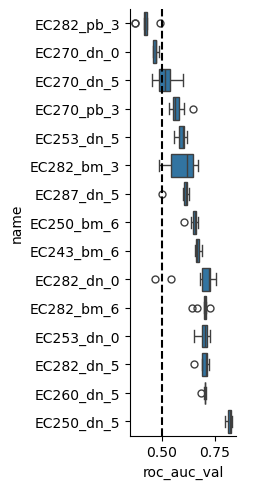

In [14]:
order = decoder_results.groupby("name").roc_auc_val.agg(["mean", "std"]).sort_values("mean").index
g = sns.catplot(data=decoder_results.reset_index(), x="roc_auc_val", y="name", order=order, kind="box", aspect=0.5, height=5)
g.axes.flat[0].axvline(0.5, color="k", linestyle="--")
None

## Start B searchlight

In [15]:
searchlight_results = {}
searchlight_window_size = 0.2
searchlight_window_start = 0.5
searchlight_window_end = 2.9
searchlight_num_quantiles = 3

searchlight_method = "spearmanr"  # ttest, spearmanr, or pearsonr

# pre-compute p(gt phoneme) for all experiments
searchlight_decoder_outputs = {}
for experiment in populations_dict.keys():
    subject, phoneme_pair, population_A = experiment
    
    p_gt_phoneme = np.array([all_results_meta[(experiment, repeat)].p_gt_phoneme
                             for repeat in range(n_repeats)]).T
    p_gt_phoneme_mean = p_gt_phoneme.mean(1)

    searchlight_decoder_outputs[experiment] = {
        "p_gt_phoneme_mean": p_gt_phoneme_mean,
    }

searchlight_electrode_activations = {}
for experiment in tqdm(populations_dict.keys()):
    subject, phoneme_pair, population_A = experiment
    result_key = (subject, phoneme_pair, population_A)
    prev_results = all_results_meta[experiment, 0]

    population_spec = populations_dict[experiment]
    population_A_start_window, population_A_end_window = population_spec["window_a"]

    # searchlight window should start at earliest at the end of population A window.
    # override the global setting if this is not true for this population A.
    this_searchlight_window_start = max(population_A_end_window, searchlight_window_start)
    # but if we shifted, make sure it is still aligned to searchlight_window_start + n * searchlight_window_size
    if (this_searchlight_window_start - searchlight_window_start) % searchlight_window_size != 0:
        this_searchlight_window_start += searchlight_window_size - \
            ((this_searchlight_window_start - searchlight_window_start) % searchlight_window_size)

    searchlight_window_size_samp = int(searchlight_window_size * prev_results.epochs.info["sfreq"])
    searchlight_window_start_samp = prev_results.epochs.time_as_index(this_searchlight_window_start)[0]
    searchlight_window_end_samp = prev_results.epochs.time_as_index(searchlight_window_end)[0]

    # outcome from A population which will be correlated with HGA: p(gt phoneme)
    p_gt_phoneme_mean = searchlight_decoder_outputs[experiment]["p_gt_phoneme_mean"]
    p_gt_phoneme_binned = pd.qcut(p_gt_phoneme_mean, searchlight_num_quantiles)
    # control quantity: `resampled` value for the trial
    control_predictor = prev_results.test_trial_metadata.resampled

    window_starts = np.arange(
        searchlight_window_start_samp,
        searchlight_window_end_samp - searchlight_window_size_samp,
        searchlight_window_size_samp
    )
    window_ends = window_starts + searchlight_window_size_samp

    if searchlight_method in ["spearmanr", "pearsonr"]:
        eval_epochs = prev_results.epochs[prev_results.test_trial_metadata.index]

        mask_left = eval_epochs.metadata.lexical_evidence == 0

        eval_epochs_left = eval_epochs[mask_left]
        eval_epochs_right = eval_epochs[~mask_left]

        eval_epochs_left = eval_epochs_left.get_data()
        eval_epochs_right = eval_epochs_right.get_data()

        for window_start, window_end in zip(window_starts, window_ends):
            # get the data for this window
            window_data_left = eval_epochs_left[:, :, window_start:window_end]
            window_data_right = eval_epochs_right[:, :, window_start:window_end]

            # average across time
            window_data_left_mean = window_data_left.mean(2)
            window_data_right_mean = window_data_right.mean(2)

            searchlight_electrode_activations[*experiment, window_start, window_end] = {
                "metadata": prev_results.test_trial_metadata,
                "mask_left": mask_left,
                "window_data_left_mean": window_data_left_mean,
                "window_data_right_mean": window_data_right_mean,
                "control_predictor": control_predictor,
            }

            results, control_results = {}, {}
            for side, window_data_mean, p_gt_phoneme_mean_side, control_predictor_side in [
                    ("left", window_data_left_mean, p_gt_phoneme_mean[mask_left], control_predictor[mask_left]),
                    ("right", window_data_right_mean, p_gt_phoneme_mean[~mask_left], control_predictor[~mask_left])]:

                if searchlight_method == "spearmanr":
                    side_test = [spearmanr(window_data_mean[:, i], p_gt_phoneme_mean_side)
                                 for i in range(window_data_mean.shape[1])]
                    corr, pval = zip(*side_test)

                    control_side_test = [spearmanr(window_data_mean[:, i], control_predictor_side)
                                         for i in range(window_data_mean.shape[1])]
                    control_corr, control_pval = zip(*control_side_test)
                elif searchlight_method == "pearsonr":
                    corr, pval = pearsonr(window_data_mean, p_gt_phoneme_mean_side[:, None], axis=0)
                    control_corr, control_pval = pearsonr(window_data_mean, control_predictor_side[:, None], axis=0)
                results[side] = (corr, pval)
                control_results[side] = (control_corr, control_pval)

            # save results
            searchlight_results[*result_key, window_start] = pd.DataFrame({
                "corr_left": results["left"][0],
                "p_val_left": results["left"][1],
                "corr_right": results["right"][0],
                "p_val_right": results["right"][1],

                "control_corr_left": control_results["left"][0],
                "control_p_val_left": control_results["left"][1],
                "control_corr_right": control_results["right"][0],
                "control_p_val_right": control_results["right"][1],

                "electrode_idx": np.arange(len(results["left"][0])),
                "electrode_in_A": np.isin(np.arange(len(results["left"][0])),
                                          population_spec["electrodes_a"]),
                "window_start_samp": window_start,
                "window_end_samp": window_end,
                "window_start": prev_results.epochs.times[window_start],
                "window_end": prev_results.epochs.times[window_end],
                "population_A": population_A,
                "phoneme_pair": phoneme_pair,
                "subject": subject,
            })
    elif searchlight_method == "ttest":
        raise NotImplementedError("T-test searchlight not implemented in this refactor.")
        left_extreme, right_extreme = p_gt_phoneme_binned.categories[[0, -1]]

        left_md = prev_results.test_trial_metadata[p_gt_phoneme_binned == left_extreme]
        right_md = prev_results.test_trial_metadata[p_gt_phoneme_binned == right_extreme]

        left_epochs = prev_results.epochs[left_md.index]
        right_epochs = prev_results.epochs[right_md.index]

        left_data = left_epochs.get_data()
        right_data = right_epochs.get_data()

        for window_start, window_end in zip(window_starts, window_ends):
            # get the data for this window
            left_window_data = left_data[:, :, window_start:window_end]
            right_window_data = right_data[:, :, window_start:window_end]

            # average across time
            left_window_data_mean = left_window_data.mean(2)
            right_window_data_mean = right_window_data.mean(2)

            # t-test
            t_stat, p_val = ttest_ind(left_window_data_mean, right_window_data_mean, axis=0)

            # save results
            searchlight_results[*result_key, window_start] = pd.DataFrame({
                "t_stat": t_stat,
                "p_val": p_val,
                "electrode_idx": np.arange(len(t_stat)),
                "window_start_samp": window_start,
                "window_end_samp": window_end,
                "population_A": population_A,
                "phoneme_pair": phoneme_pair,
                "subject": subject,
            })

  0%|          | 0/15 [00:00<?, ?it/s]

In [16]:
searchlight_results_df = pd.concat(searchlight_results.values())
searchlight_results_df["sig_left"] = searchlight_results_df.p_val_left < 0.001
searchlight_results_df["sig_right"] = searchlight_results_df.p_val_right < 0.001

In [17]:
# Only retain results for which we have electrode metadata
searchlight_results_df = electrode_df.merge(searchlight_results_df, left_index=True, right_on=["subject", "electrode_idx"], how="inner")
searchlight_results_df["p_val_min"] = searchlight_results_df[["p_val_left", "p_val_right"]].min(axis=1)
searchlight_results_df = searchlight_results_df.sort_values("p_val_min").head(200)

In [18]:
plot_row = searchlight_results_df.iloc[0]
causal4.counterfactual_baseline(
    plot_row.subject, plot_row.phoneme_pair, plot_row.population_A,
    plot_row.electrode_idx, plot_row.window_start_samp, plot_row.window_end_samp,
    searchlight_decoder_outputs, searchlight_electrode_activations,
    sanity_check=True,
    left=plot_row.sig_left
)

[(('EC250', 'dn', '5'),
  SignificanceResult(statistic=-0.45751492132392835, pvalue=2.7807486667495298e-06))]

In [19]:
def counterfactual_for_row(row):
    ret = causal4.counterfactual_baseline(
        row.subject, row.phoneme_pair, row.population_A,
        row.electrode_idx, row.window_start_samp, row.window_end_samp,
        searchlight_decoder_outputs, searchlight_electrode_activations,
        sanity_check=False,
        left=row.sig_left
    )

    counterfactual_df = pd.DataFrame([
        {
            "subject": subject,
            "phoneme_pair": phoneme_pair,
            "population_A": population_A,
            "spearmanr": stat.statistic,
            "p_val": stat.pvalue,
        }
        for (subject, phoneme_pair, population_A), stat in ret
    ])
    # Fisher z-transform the Spearman correlation
    counterfactual_df["spearmanr_z"] = np.arctanh(counterfactual_df.spearmanr)

    # compute statistic on the observed Spearman correlation
    spearmanr_obs = row.corr_left if row.p_val_left < row.p_val_right else row.corr_right
    z_stat = (np.arctanh(spearmanr_obs) - counterfactual_df.spearmanr_z.mean()) / counterfactual_df.spearmanr_z.std()
    dof = len(counterfactual_df) - 1  # degrees of freedom
    p_value = 2 * stats.t.sf(np.abs(z_stat), dof)

    return pd.Series({
        "counterfactual_spearmanr": counterfactual_df.spearmanr.mean(),
        "counterfactual_spearmanr_list": counterfactual_df.spearmanr.tolist(),
        "counterfactual_spearmanr_z": counterfactual_df.spearmanr_z.mean(),

        "counterfactual_test_z": z_stat,
        "counterfactual_test_p": p_value,
        "counterfactual_n": len(counterfactual_df),
    })

In [20]:
searchlight_results_df = pd.concat([
    searchlight_results_df,
    searchlight_results_df.progress_apply(counterfactual_for_row, axis=1)
], axis=1)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# cache z-score parameters for each subject and electrode
parameter_cache = {}

def plot_searchlight_response(row):
    subject = row.subject
    phoneme_pair = row.phoneme_pair
    population_A = row.population_A
    population_B = [row.electrode_idx]
    population_B_window = (row.window_start_samp, row.window_end_samp)
    
    plot_key = (subject, phoneme_pair, population_A)
    plot_num_quantiles = 4
    plot_meta = all_results_meta[plot_key, 0]

    # sanity check: test trials are the same across repeats
    test_trial_indices = np.array([all_results_meta[(plot_key, repeat)].test_trial_metadata.index
                                    for repeat in range(n_repeats)]).T
    for i in range(1, test_trial_indices.shape[1]):
        np.testing.assert_array_equal(
            test_trial_indices[:, i],
            test_trial_indices[:, 0],
        )

    # merge estimated probabilities from repeats
    p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)].p_gt_phoneme
                            for repeat in range(n_repeats)]).T
    p_gt_phoneme_binned = pd.qcut(p_gt_phoneme.mean(1), plot_num_quantiles)

    plot_meta_df = plot_meta.test_trial_metadata.copy()
    plot_meta_df["p_gt_phoneme"] = p_gt_phoneme.mean(1)
    plot_meta_df["p_gt_phoneme_binned"] = p_gt_phoneme_binned
    plot_meta_df["p_gt_phoneme_bin_center"] = plot_meta_df.p_gt_phoneme_binned.apply(
        lambda x: x.mid
    ).astype(float).round(3)

    def get_textgrid_path(row):
        return Path(tg_dir) / (Path(row.wav_file).with_suffix(".TextGrid").name)
    plot_meta_df["textgrid_path"] = plot_meta_df.apply(get_textgrid_path, axis=1)
    plot_meta_df = plot_meta_df.rename_axis("epoch_idx").reset_index()

    # cross by electrodes
    plot_meta_df = pd.merge(plot_meta_df,
                 electrode_df.loc[plot_meta.subject].loc[population_B].reset_index(),
                 how="cross")

    ####

    g_scatter = causal4.plot_causal4_scatter(
        plot_meta, plot_meta_df, subject, population_B_window)

    ####

    # displot showing spearmanr results
    spearmanr_results = np.array(row.counterfactual_spearmanr_list)
    g_displot = sns.displot(
        spearmanr_results,
        kind="kde", fill=True, color="blue",
        height=2.5, aspect=3,
    )
    spearmanr_obs = row.corr_left if row.p_val_left < row.p_val_right else row.corr_right
    g_displot.ax.axvline(spearmanr_obs, color="red", linestyle="--", label="Observed", linewidth=2)
    g_displot.ax.set_xlabel("Spearman correlation")
    g_displot.ax.set_title(f"Permutation baseline results\n(z={row.counterfactual_test_z:.2f}, p={row.counterfactual_test_p:.2g})")

    ####

    g = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_B_window,
        hue="p_gt_phoneme_bin_center"
    )

    ####

    # plot re-aligned to behavior
    def plot_facet_evoked_align_behavior(data, color, **kwargs):
        electrode_idx = data.electrode_idx.iloc[0]
        epoch_idxs = data.epoch_idx

        word_end = data.word_end.iloc[0]
        tg_path = data.textgrid_path.iloc[0]
        tg = textgrid.TextGrid.fromFile(str(tg_path))

        ax = plt.gca()
        ax.set_xlabel("Time relative to behavior onset (sec)")
        ax.set_ylabel("HGA")
        ax.set_title(f"{subject} {electrode_idx + 1}, {word_end}")

        # plot epoched response at this electrode
        plot_epochs = plot_meta.epochs[epoch_idxs]
        plot_epochs = causal4.realign_epochs_by_behavior(plot_epochs)

        plot_epoch_data = plot_epochs.copy().pick(electrode_idx).get_data().squeeze(1)
        assert plot_epoch_data.ndim == 2  # n_trials * n_times

        plot_times = plot_epochs.times
        plot_epoch_data_mean = np.nanmean(plot_epoch_data, 0)
        plot_epoch_data_sem = np.nanstd(plot_epoch_data, 0) / np.sqrt((~np.isnan(plot_epoch_data)).sum(0))
        ax.plot(plot_times, plot_epoch_data_mean, color=color, alpha=0.5, **kwargs)
        ax.fill_between(plot_times, plot_epoch_data_mean - plot_epoch_data_sem,
                        plot_epoch_data_mean + plot_epoch_data_sem, color=color, alpha=0.2)
        
        ax.set_xlim(plot_epochs.times[0], plot_epochs.times[-1])

        return ax
    
    g_evoked_by_behavior = sns.FacetGrid(
        plot_meta_df,
        row="electrode_idx",
        hue="p_gt_phoneme_bin_center", palette="plasma",
        col="lexical_evidence",
        aspect=3, height=3, sharey="row"
    ).map_dataframe(plot_facet_evoked_align_behavior).add_legend()
    g_evoked_by_behavior.fig.suptitle("Evoked responses by P(gt phoneme), aligned to behavior onset")

    ####

    g_evoked_resampled = causal4.plot_causal4_evoked(
        plot_meta, plot_meta_df, subject, population_B_window,
        hue="resampled"
    )

    ####

    g_raster = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        sort_by="p_gt_phoneme", parameter_cache=parameter_cache)
    
    g_raster_resampled = causal4.plot_causal4_raster(
        plot_meta, plot_meta_df, subject, population_B_window,
        sort_by="resampled", parameter_cache=parameter_cache)

    return (g_scatter, g_displot,
            g, g_evoked_by_behavior, g_evoked_resampled,
            g_raster, g_raster_resampled)

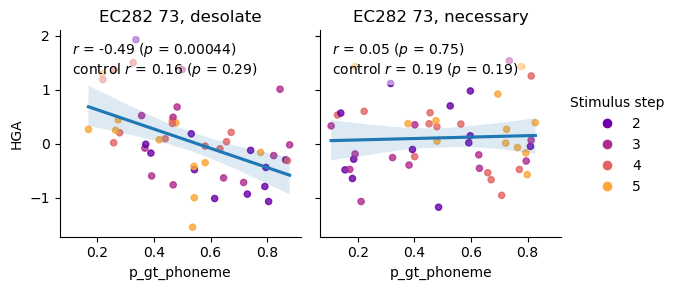

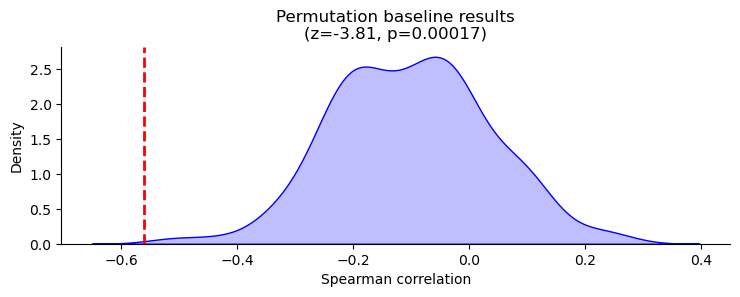

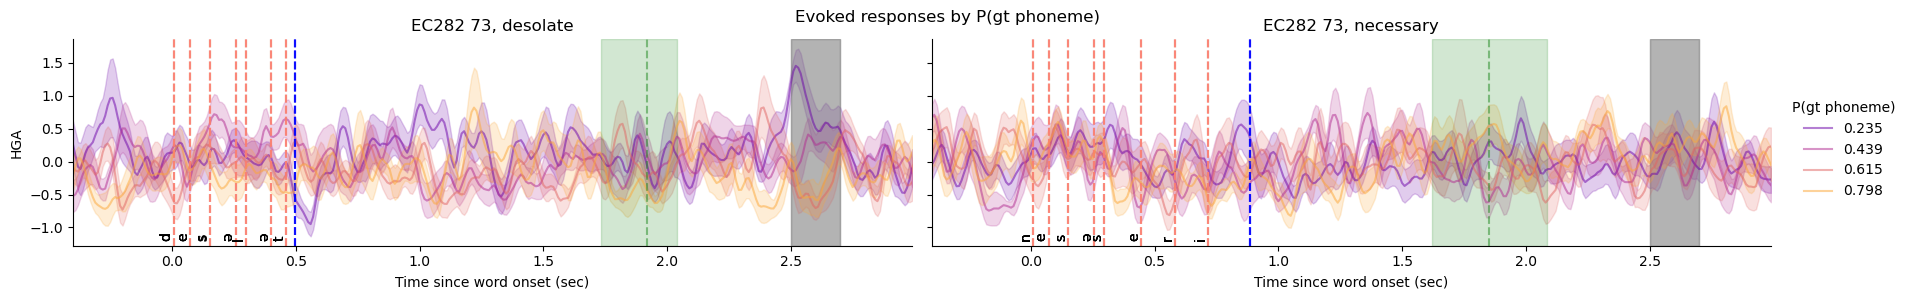

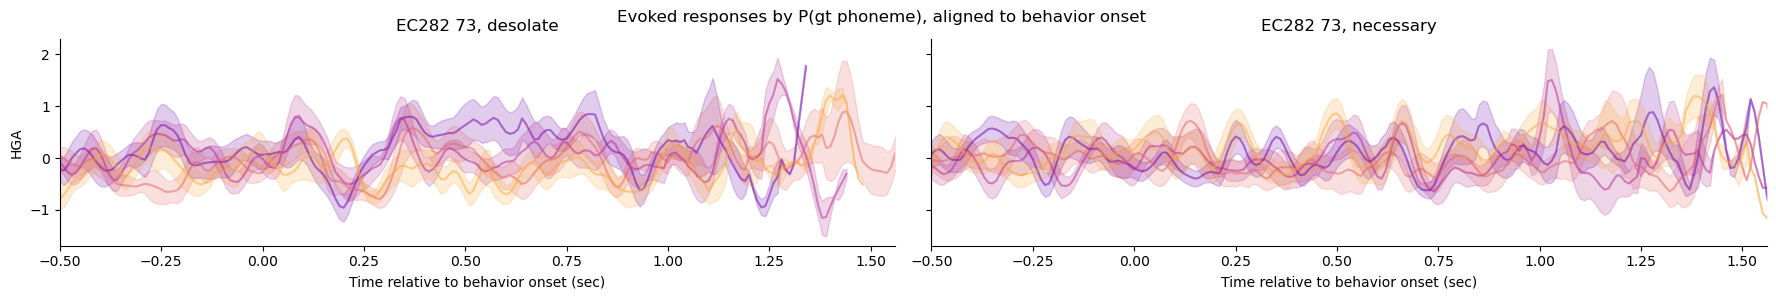

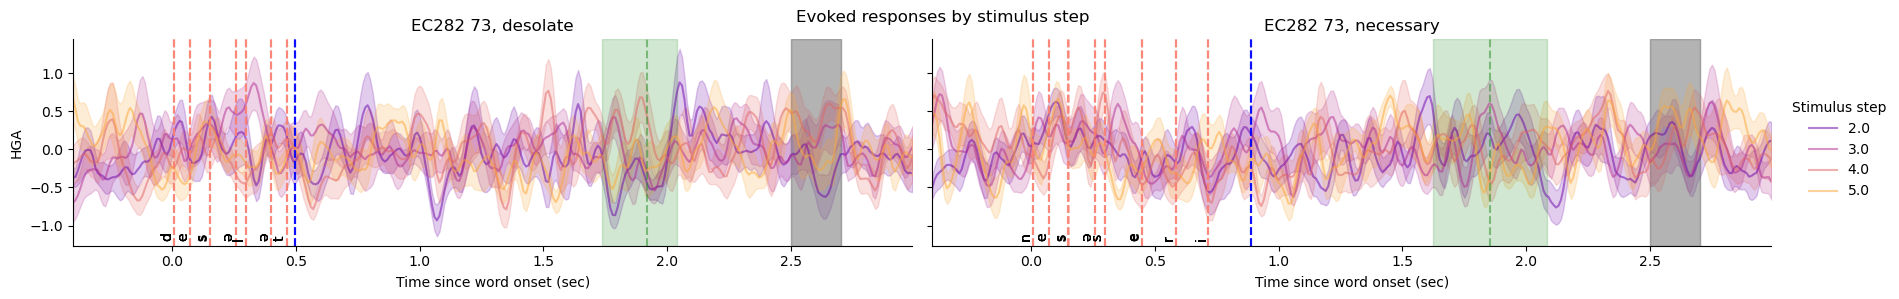

In [372]:
plot_row =  searchlight_results_df.iloc[7]
plot_searchlight_response(plot_row)
None

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("searchlight_results.pdf") as pdf:
    for _, row in tqdm(searchlight_results_df.sort_values("p_val_min").iterrows(), total=len(searchlight_results_df)):
        facetgrids = plot_searchlight_response(row)
        for fg in facetgrids:
            fg.tight_layout()
            pdf.savefig(fg.fig)
            plt.close(fg.fig)

  0%|          | 0/200 [00:00<?, ?it/s]

In [244]:
searchlight_results_df.to_csv("causal4_searchlight_results.csv")

In [ ]:
# Load results with manual annotations
searchlight_manual = pd.read_csv("causal4_searchlight_results_manual.csv", index_col=0)

In [357]:
realign_epochs_by_behavior(epochs["EC282"])

Adding metadata with 100 columns
421 matching events found
No baseline correction applied
0 projection items activated


<EpochsArray | 421 events (all good), -0.5 – 2.45 s (baseline off), ~213.1 MiB, data loaded, with metadata,
 '1': 421>

In [ ]:
if not (searchlight_manual.index == searchlight_results_df.index).all():
    raise ValueError("Manual annotations do not match the current searchlight results. "
                     "Probably need to repeat manual annotations.")

In [135]:
all_results_meta.keys()

dict_keys([(('EC282', 'dn', '5'), 0), (('EC253', 'dn', '0'), 0), (('EC282', 'dn', '0'), 0), (('EC270', 'dn', '5'), 0), (('EC253', 'dn', '5'), 0), (('EC287', 'dn', '5'), 0), (('EC282', 'bm', '3'), 0), (('EC270', 'dn', '0'), 0), (('EC250', 'dn', '5'), 0), (('EC260', 'dn', '5'), 0), (('EC282', 'bm', '6'), 0), (('EC243', 'bm', '6'), 0), (('EC270', 'pb', '3'), 0), (('EC282', 'pb', '3'), 0), (('EC250', 'bm', '6'), 0), (('EC282', 'dn', '5'), 1), (('EC253', 'dn', '0'), 1), (('EC282', 'dn', '0'), 1), (('EC270', 'dn', '5'), 1), (('EC253', 'dn', '5'), 1), (('EC287', 'dn', '5'), 1), (('EC282', 'bm', '3'), 1), (('EC270', 'dn', '0'), 1), (('EC250', 'dn', '5'), 1), (('EC260', 'dn', '5'), 1), (('EC282', 'bm', '6'), 1), (('EC243', 'bm', '6'), 1), (('EC270', 'pb', '3'), 1), (('EC282', 'pb', '3'), 1), (('EC250', 'bm', '6'), 1), (('EC282', 'dn', '5'), 2), (('EC253', 'dn', '0'), 2), (('EC282', 'dn', '0'), 2), (('EC270', 'dn', '5'), 2), (('EC253', 'dn', '5'), 2), (('EC287', 'dn', '5'), 2), (('EC282', 'bm', 

Not setting metadata
192 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_2934426/3250237573.py:14: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  plot_ep.plot_image(


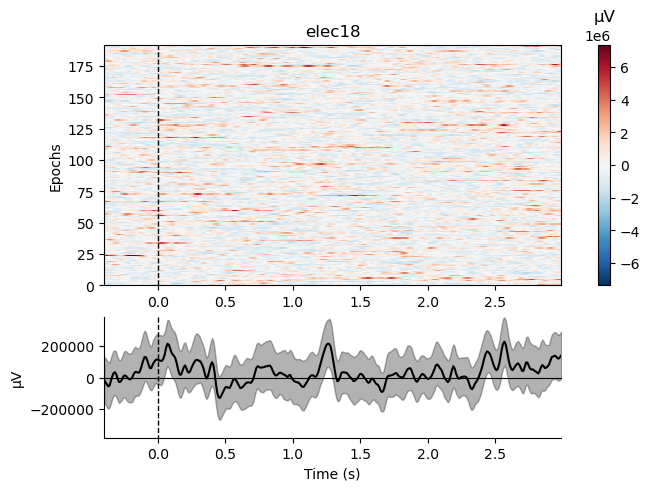

[<Figure size 640x480 with 3 Axes>]

In [136]:
plot_subject = "EC260"
plot_electrode_idx = 18
plot_phoneme_pair = "dn"
plot_population_A = "5"
plot_key = (plot_subject, plot_phoneme_pair, plot_population_A)

plot_results = all_results_meta[plot_key, 0]
plot_ep = plot_results.epochs[plot_results.test_trial_metadata.index]
p_gt_phoneme = np.array([all_results_meta[(plot_key, repeat)].p_gt_phoneme
                            for repeat in range(n_repeats)]).T
p_gt_phoneme = p_gt_phoneme.mean(1)

rts = plot_ep.metadata["slider.rt"].combine(plot_ep.tmax, min)
plot_ep.plot_image(
    picks=[plot_electrode_idx],
    # overlay_times=rts,
    order=p_gt_phoneme.argsort())

In [ ]:
prev_results.epochs.plot_image(picks=[])

In [ ]:
searchlight_manual

## Cross-reference with EOIs

In [91]:
searchlight_results_df.head()[["subject", "electrode_idx"]]

,subject,electrode_idx
201,EC250,201
219,EC260,219
74,EC270,74
172,EC282,172
203,EC282,203


In [76]:
eoi_df = pd.read_csv("outputs/trf_eois/eois.csv")

In [79]:
eoi_df

,subject,feature_block,electrode,unique_variance
0,EC250,acoustic,215,0.017799
1,EC282,acoustic,84,0.011961
2,EC248,acoustic,382,0.011833
3,EC243,mismatch,102,0.011563
4,EC260,mismatch,204,0.011078
...,...,...,...,...
524,EC278,mismatch,41,-0.004567
525,EC253,mismatch,3,-0.004804
526,EC253,mismatch,122,-0.005145
527,EC253,mismatch,23,-0.005581


In [82]:
eoi_df_wide = eoi_df.rename(columns={"electrode": "electrode_idx"}).pivot_table(index=["subject", "electrode_idx"], columns="feature_block", values="unique_variance")
eoi_df_wide

feature_block          acoustic  lexical_evidence  mismatch
subject electrode_idx                                      
EC243   59            -0.000017         -0.000487 -0.001147
        71             0.001822         -0.000356 -0.002087
        72            -0.000048         -0.000607  0.000116
        87             0.002814         -0.001063 -0.000427
        88             0.001250         -0.000704 -0.002367
...                         ...               ...       ...
EC287   76                  NaN         -0.001539 -0.000273
        124            0.000033          0.000114  0.000891
        146           -0.001936               NaN -0.001755
        147           -0.000032          0.002225 -0.001596
        182            0.000048         -0.000447 -0.000579

[194 rows x 3 columns]

In [84]:
mrg = pd.merge(searchlight_results_df, eoi_df_wide, left_on=["subject", "electrode_idx"], right_index=True, how="left")
mrg

,long_name,type,roi,corr_left,p_val_left,corr_right,p_val_right,control_corr_left,control_p_val_left,control_corr_right,...,p_val_min,counterfactual_spearmanr,counterfactual_spearmanr_list,counterfactual_spearmanr_z,counterfactual_test_z,counterfactual_test_p,counterfactual_n,acoustic,lexical_evidence,mismatch
201,Inferior74,grid,superiortemporal,-0.097179,0.346239,-0.457515,0.000003,0.103218,0.316946,-0.321757,...,0.000003,-0.071933,"[-0.172856170260066, -0.15579869894679413, -0....",-0.072711,-4.334682,2.580282e-05,160,-0.000504,0.001723,NaN
219,TemporalGrid92,grid,superiortemporal,0.389460,0.000088,-0.456606,0.000003,-0.071278,0.490129,-0.436407,...,0.000003,0.007485,"[0.06823109272313659, -0.026097934823209448, 0...",0.007624,-4.414967,1.858110e-05,160,-0.002268,0.002065,0.004416
74,Temporal75,grid,superiortemporal,0.160877,0.274682,-0.611594,0.000004,0.025556,0.863106,-0.110296,...,0.000004,-0.030840,"[0.03484585323491098, -0.07121146330872774, 0....",-0.031338,-5.105612,7.540096e-07,205,NaN,NaN,NaN
172,Insula7,depth,ctx_lh_S_circular_insula_sup,0.580873,0.000015,0.099218,0.502256,0.084740,0.566881,0.063219,...,0.000015,-0.025076,"[-0.07653061224489796, -0.03810247503256621, -...",-0.025103,9.437711,7.028432e-04,5,NaN,NaN,NaN
203,Amygdala2,depth,Left-Hippocampus,0.022688,0.878349,0.573817,0.000020,-0.201762,0.169073,0.169480,...,0.000020,0.073708,"[0.07913590968302216, 0.23415110725141122, 0.0...",0.075340,4.136932,4.761659e-05,260,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,FrontalGrid45,grid,precentral,0.319872,0.001488,-0.117987,0.252254,-0.073967,0.473858,-0.063881,...,0.001488,-0.012285,"[-0.016347333801117917, 0.14326728202653885, -...",-0.012236,2.951765,3.443762e-03,265,NaN,NaN,NaN
227,PosteriorGrid100,grid,superiortemporal,-0.319723,0.001496,0.059645,0.563768,0.132132,0.199386,-0.021182,...,0.001496,-0.004102,"[0.30287796987416615, -0.08980454408543602, 0....",-0.004183,-2.908474,3.947082e-03,260,0.001247,0.001009,-0.001074
45,AnteriorGrid46,grid,precentral,0.319031,0.001534,0.059075,0.567504,-0.101201,0.326547,0.103218,...,0.001534,0.021819,"[0.15612342565172851, 0.081345569737253, 0.067...",0.022018,3.232131,1.387900e-03,260,NaN,NaN,NaN
163,SuperiorParietal36,grid,precentral,0.054300,0.599272,0.318896,0.001542,0.003698,0.971472,0.185254,...,0.001542,0.056153,"[0.011898543379325483, -0.11042654492626756, 0...",0.056664,2.730388,7.431458e-03,105,NaN,NaN,NaN


In [107]:
mrg.loc[mrg.p_val_min == mrg.p_val_left, "corr_best"] = mrg.loc[mrg.p_val_min == mrg.p_val_left, "corr_left"].abs()
mrg.loc[mrg.p_val_min == mrg.p_val_right, "corr_best"] = mrg.loc[mrg.p_val_min == mrg.p_val_right, "corr_right"].abs()
mrg["log_p_val_min"] = -np.log10(mrg.counterfactual_test_p)

<Axes: xlabel='log_p_val_min', ylabel='lexical_evidence'>

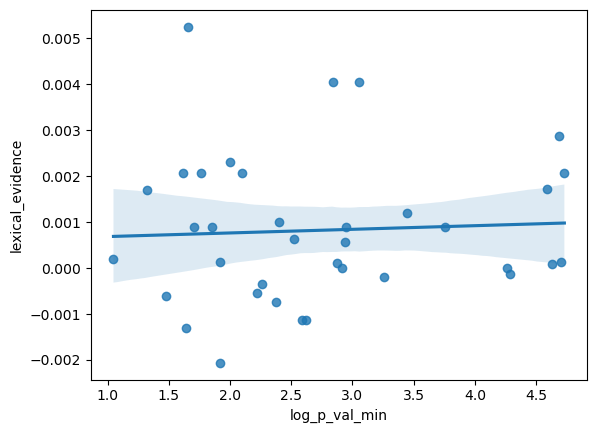

In [111]:
sns.regplot(data=mrg.reset_index(), x="log_p_val_min", y="lexical_evidence")

## Cross-reference with single electrode decoding

In [130]:
dec_df = pd.read_csv("outputs/single_electrode_decoding/10/mismatch/scores.csv")

In [131]:
dec_summary = dec_df.groupby(["subject", "electrode_idx", "phoneme_pair"]).roc_auc.max()

In [132]:
mrg = pd.merge(searchlight_results_df,
         dec_summary.rename("lexical_evidence_roc_auc"),
         left_on=["subject", "electrode_idx", "phoneme_pair"],
         right_index=True, how="left")

mrg["log_p_val_min"] = -np.log10(mrg.p_val_min)

<Axes: xlabel='log_p_val_min', ylabel='lexical_evidence_roc_auc'>

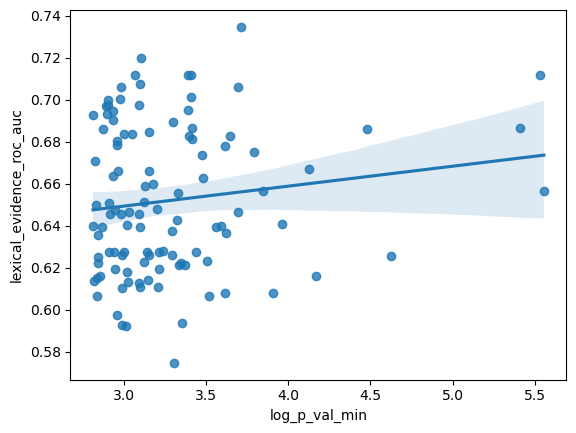

In [133]:
sns.regplot(data=mrg.reset_index(), x="log_p_val_min", y="lexical_evidence_roc_auc",)